# Chapter 2 (Hull) — Futures Markets & Central Counterparties

In Chapter 2, Hull explains how futures markets operate in practice.  
We keep it **simple** and focus on three ideas shown in the excerpt:

1. **Price quotes** (how exchanges quote prices)
2. **Price limits & position limits**
3. **Convergence of futures price to spot price** as delivery approaches

We add small Python illustrations (no advanced modeling).

## 1) Price Quotes

An exchange defines **how prices are quoted**.

Examples (Hull):
- Some futures (e.g., crude oil) can be quoted in **dollars and cents**.
- Treasury bond/note futures can be quoted in **fractions of a dollar** (e.g., 32nds).

**Key idea:** the quote convention is part of the contract specification.
This matters because a "one tick" move depends on the quote format.

In [ ]:
# Simple "tick value" illustration (generic)

contract_size = 1000  # e.g., 1000 units of the underlying (example)
tick_size = 0.01      # quoted in dollars and cents -> one tick = $0.01
tick_value = contract_size * tick_size

print(f"If tick size = ${tick_size} and contract size = {contract_size} units,")
print(f"then 1 tick move = ${tick_value:.2f} per contract.")

If tick size = $0.01 and contract size = 1000 units,
then 1 tick move = $10.00 per contract.


> In real contracts, both **contract size** and **tick size** are standardized by the exchange.

## 2) Price Limits and Position Limits

### 2.1 Daily price limits (limit up / limit down)

For many contracts, exchanges impose **daily price movement limits**.

- If the price drops by the maximum allowed amount relative to the previous close → **limit down**
- If it rises by the maximum allowed amount → **limit up**
- Often, trading can slow down or stop for the day when the limit is reached.

**Purpose (Hull):**
- reduce very large one-day moves driven by speculative excesses
- but limits can also create friction when prices need to adjust quickly

### 2.2 Position limits

Exchanges can limit the **maximum number of contracts** a speculator can hold.

**Purpose (Hull):**
- prevent any participant from having undue influence on the market

In [ ]:
import numpy as np

# Toy example: a series of daily closes
closes = np.array([100, 102, 97, 95, 99, 105, 110], dtype=float)

daily_limit = 5.0  # max allowed move from previous close (in $ for this toy example)

def classify_limits(closes, limit):
    labels = []
    for t in range(1, len(closes)):
        move = closes[t] - closes[t-1]
        if move <= -limit:
            labels.append("LIMIT DOWN")
        elif move >= limit:
            labels.append("LIMIT UP")
        else:
            labels.append("NORMAL")
    return labels

labels = classify_limits(closes, daily_limit)

print("PrevClose -> Close | Move | Status")
for t in range(1, len(closes)):
    move = closes[t] - closes[t-1]
    print(f"{closes[t-1]:7.2f} -> {closes[t]:7.2f} | {move:6.2f} | {labels[t-1]}")

PrevClose -> Close | Move | Status
 100.00 ->  102.00 |   2.00 | NORMAL
 102.00 ->   97.00 |  -5.00 | LIMIT DOWN
  97.00 ->   95.00 |  -2.00 | NORMAL
  95.00 ->   99.00 |   4.00 | NORMAL
  99.00 ->  105.00 |   6.00 | LIMIT UP
 105.00 ->  110.00 |   5.00 | LIMIT UP


> This is a **didactic** detection.  
> In real markets, limits can depend on the contract, exchange rules, and may trigger halts.

## 3) Convergence of Futures Price to Spot Price (Hull §2.3)

Hull’s core message:

As the delivery period approaches, the **futures price converges to the spot price**:

\[
F_t \to S_t \quad \text{as } t \to T
\]

### Why?

If, near delivery, the futures price were **above** the spot price (too expensive),
traders can lock in an arbitrage (Hull’s 3 steps):

1. **Sell (short)** the futures contract  
2. **Buy** the underlying asset in the spot market  
3. **Make delivery** (deliver the asset into the futures contract)

This pushes the futures price down and/or the spot price up, removing the gap.

Similarly, if the futures price is **below** the spot price near delivery,
an opposite trade becomes attractive (buy futures, short/borrow the asset if possible),
pushing futures up and/or spot down.

**Result:** the gap cannot persist close to delivery ⇒ convergence.

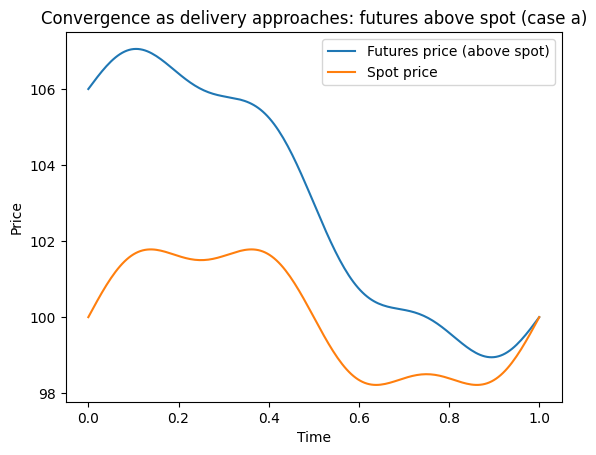

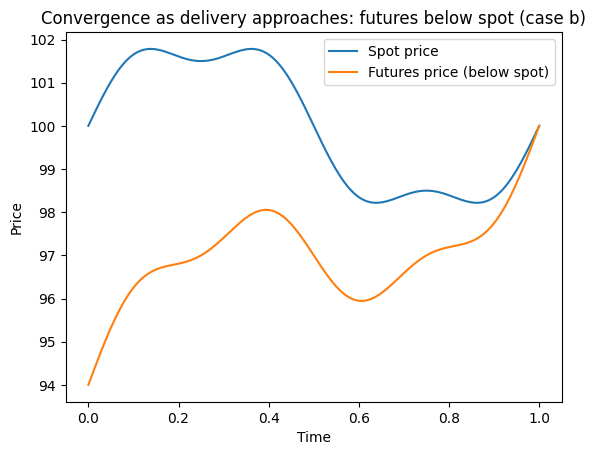

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

T = 1.0
n = 200
t = np.linspace(0, T, n)

# Toy spot path (smooth)
spot = 100 + 2*np.sin(2*np.pi*t) + 0.5*np.sin(6*np.pi*t)

# Case (a): futures above spot then converges
basis_a = 6 * (1 - t/T)          # starts at +6, goes to 0
futures_a = spot + basis_a

# Case (b): futures below spot then converges
basis_b = -6 * (1 - t/T)         # starts at -6, goes to 0
futures_b = spot + basis_b

plt.figure()
plt.plot(t, futures_a, label="Futures price (above spot)")
plt.plot(t, spot, label="Spot price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Convergence as delivery approaches: futures above spot (case a)")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, spot, label="Spot price")
plt.plot(t, futures_b, label="Futures price (below spot)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Convergence as delivery approaches: futures below spot (case b)")
plt.legend()
plt.show()

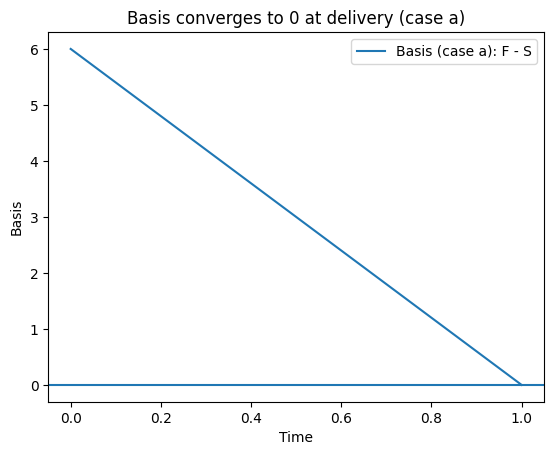

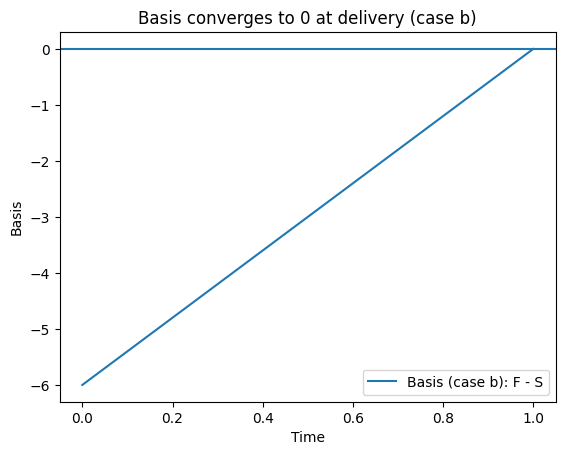

In [ ]:
basis_a_series = futures_a - spot
basis_b_series = futures_b - spot

plt.figure()
plt.plot(t, basis_a_series, label="Basis (case a): F - S")
plt.axhline(0)
plt.xlabel("Time")
plt.ylabel("Basis")
plt.title("Basis converges to 0 at delivery (case a)")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, basis_b_series, label="Basis (case b): F - S")
plt.axhline(0)
plt.xlabel("Time")
plt.ylabel("Basis")
plt.title("Basis converges to 0 at delivery (case b)")
plt.legend()
plt.show()


**Interpretation:**
- The **basis** is \(F_t - S_t\).
- Hull’s point: close to delivery, arbitrage forces the basis toward **0**.

## Summary (Hull-level)

- **Price quotes:** exchanges define how prices are expressed (format matters for ticks).
- **Daily price limits:** can force “limit up/limit down” and sometimes trading halts.
- **Position limits:** restrict the number of contracts a speculator may hold.
- **Convergence:** as delivery approaches, futures and spot prices converge,
  because persistent differences create arbitrage opportunities.